# ML/03 — NDVI Regression

Within the cannabis suitability zone (cluster 0), what environmental
features best predict vegetation vigor (NDVI std)?

**Why NDVI std and not mean:** In a uniformly forested landscape, NDVI mean
is near-constant. NDVI std captures within-cell heterogeneity — patches of
high-vigor canopy mixed with clearings, roads, or disturbed ground. That
texture signal is more informative than mean greenness in this landscape.

**Approach:**
- Fit a Random Forest regressor on cluster-0 cells only
- Target: `ndvi_std`
- Features: terrain + climate + soil
- Compare feature importance inside the suitability zone vs. full landscape
- Partial dependence plots for the top drivers

**Outputs:**
- `img/ML03_ndvi_importance.png`
- `img/ML03_ndvi_pdp.png`
- `data/processed/ndvi_model.pkl`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import r2_score
import pickle

PROC = Path('../data/processed')
RAW  = Path('../data/raw')
IMG  = Path('../img')

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


## 1. Load data — suitability zone cells only

In [2]:
features = pd.read_pickle(PROC / 'features.pkl')
clusters = pd.read_pickle(PROC / 'clusters.pkl')

df = features.merge(clusters, on='cell_id')

# Suitability zone only
cannabis = df[df['cluster'] == 0].copy().reset_index(drop=True)
print(f'Suitability zone cells: {len(cannabis):,}')

feature_cols = [c for c in features.columns
                if c not in ('cell_id', 'cluster')
                and c != 'ndvi_std'    # target
                and c != 'ndvi_mean'   # dropped in 07
               ]

# Drop target NaNs
cannabis = cannabis[cannabis['ndvi_std'].notna()].reset_index(drop=True)
print(f'Cells with NDVI std: {len(cannabis):,}')

X = cannabis[feature_cols].values
y = cannabis['ndvi_std'].values
print(f'Features: {len(feature_cols)}')
print(f'Target mean: {y.mean():.4f}  std: {y.std():.4f}')

Suitability zone cells: 1,924
Cells with NDVI std: 1,924
Features: 22
Target mean: 0.1468  std: 0.0576


## 2. Fit Random Forest — cross-validated

In [3]:
rf = RandomForestRegressor(
    n_estimators=300, max_depth=10,
    min_samples_leaf=5, random_state=746837645, n_jobs=-1
)

kf = KFold(n_splits=5, shuffle=True, random_state=746837645)
cv_r2 = cross_val_score(rf, X, y, cv=kf, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(rf, X, y, cv=kf, scoring='neg_mean_squared_error'))

print(f'CV R²:   {cv_r2.mean():.3f} ± {cv_r2.std():.3f}')
print(f'CV RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}')

rf.fit(X, y)
y_pred = rf.predict(X)
print(f'Train R²: {r2_score(y, y_pred):.3f}')

CV R²:   0.650 ± 0.043
CV RMSE: 0.0339 ± 0.0017
Train R²: 0.857


### 2b. Spatial block cross-validation

Random K-fold CV on 2 km cells with strong spatial autocorrelation lets
neighboring cells land in different folds, so the model partly interpolates
rather than generalizes -- inflating CV R^2. Repeats CV with 10 km spatial
blocks as groups (`GroupKFold`) instead of random folds, so no training
cell falls within 10 km of a test-fold cell.

In [4]:
from sklearn.model_selection import GroupKFold

hex_grid = gpd.read_file(RAW / 'hex_grid.gpkg')
centroids = hex_grid.set_index('cell_id').geometry.centroid
cannabis['x'] = cannabis['cell_id'].map(lambda c: centroids[c].x)
cannabis['y'] = cannabis['cell_id'].map(lambda c: centroids[c].y)

BLOCK_SIZE = 10_000  # 10 km
block_id = ((cannabis['x'] // BLOCK_SIZE).astype(int).astype(str) + '_' +
            (cannabis['y'] // BLOCK_SIZE).astype(int).astype(str))

gkf = GroupKFold(n_splits=5)
cv_r2_block = cross_val_score(rf, X, y, cv=gkf, groups=block_id, scoring='r2')

print(f'Random 5-fold CV R^2:        {cv_r2.mean():.3f} +/- {cv_r2.std():.3f}')
print(f'Spatial block CV R^2 (10km): {cv_r2_block.mean():.3f} +/- {cv_r2_block.std():.3f}  '
      f'({block_id.nunique()} blocks)')
print(f'Per-fold block R^2: {cv_r2_block.round(3)}')
print(f'Drop: {cv_r2.mean() - cv_r2_block.mean():.3f} '
      f'({100*(cv_r2.mean()-cv_r2_block.mean())/cv_r2.mean():.0f}% relative) -- real but not devastating.')

Random 5-fold CV R^2:        0.650 +/- 0.043
Spatial block CV R^2 (10km): 0.601 +/- 0.037  (183 blocks)
Per-fold block R^2: [0.606 0.592 0.536 0.645 0.626]
Drop: 0.049 (8% relative) -- real but not devastating.


## 3. Feature importance — permutation-based

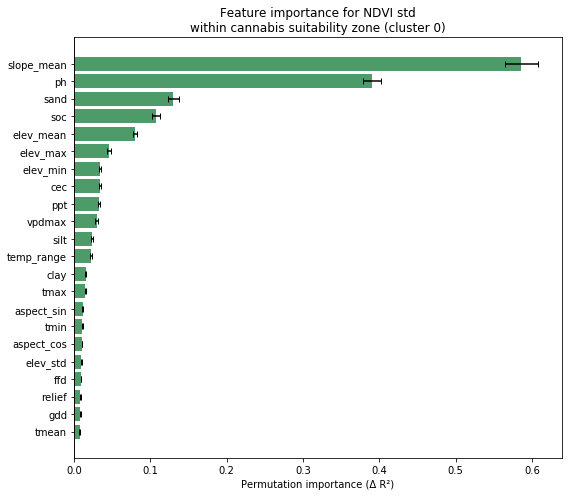

Top 5 NDVI drivers:
slope_mean    0.5862
ph            0.3901
sand          0.1301
soc           0.1075
elev_mean     0.0794


In [5]:
# Permutation importance is more reliable than Gini impurity for correlated features
perm = permutation_importance(rf, X, y, n_repeats=20, random_state=746837645, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=True)
imp_std = pd.Series(perm.importances_std, index=feature_cols)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#2d8a4e' if v > 0 else '#ccc' for v in imp.values]
ax.barh(imp.index, imp.values, xerr=imp_std[imp.index].values,
        color=colors, alpha=0.85, capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Permutation importance (Δ R²)')
ax.set_title(
    'Feature importance for NDVI std\n'
    'within cannabis suitability zone (cluster 0)',
    fontsize=12
)
plt.tight_layout()
plt.savefig('../img/ML03_ndvi_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 NDVI drivers:')
print(imp.tail(5).iloc[::-1].round(4).to_string())

### 3b. Conditional permutation importance

Marginal permutation importance (above) can inflate a feature's apparent
importance under collinearity: permuting `slope_mean` while its correlate
`relief` stays intact lets the forest partly recover the signal through
the back door. Approximates conditional importance (in the spirit of
Strobl et al. 2008's `cforest`, not available in a Python/3.7 stack) by
permuting each feature only *within strata* of its most-correlated other
feature -- this breaks the feature's own link to the target while
preserving its correlation structure with its strongest covariate.

In [6]:
def conditional_permutation_importance(rf, X, y, feature_cols, n_repeats=20, n_bins=10, random_state=746837645):
    rng = np.random.RandomState(random_state)
    Xdf = pd.DataFrame(X, columns=feature_cols)
    corr = Xdf.corr().abs()
    np.fill_diagonal(corr.values, 0)
    baseline_r2 = rf.score(X, y)
    results = {}
    for feat in feature_cols:
        partner = corr[feat].idxmax()
        strata = pd.qcut(Xdf[partner], q=n_bins, duplicates='drop', labels=False)
        deltas = []
        for _ in range(n_repeats):
            Xp = Xdf.copy()
            for s in strata.unique():
                idx = strata[strata == s].index
                if len(idx) > 1:
                    Xp.loc[idx, feat] = rng.permutation(Xp.loc[idx, feat].values)
            deltas.append(baseline_r2 - rf.score(Xp.values, y))
        results[feat] = dict(importance=np.mean(deltas), std=np.std(deltas),
                              correlated_with=partner, corr_value=corr[feat][partner])
    return pd.DataFrame(results).T

cond_df = conditional_permutation_importance(rf, X, y, feature_cols, n_repeats=10)
cond_df['importance'] = cond_df['importance'].astype(float)

compare_mc = pd.DataFrame({'marginal': imp.sort_values(ascending=False), 'conditional': cond_df['importance']})
compare_mc = compare_mc.sort_values('marginal', ascending=False)
print(compare_mc.head(6))
print()
print('Marginal top-5:   ', list(compare_mc.sort_values('marginal', ascending=False).index[:5]))
print('Conditional top-5:', list(compare_mc.sort_values('conditional', ascending=False).index[:5]))
print()
print(f"slope_mean's strongest correlate: {cond_df.loc['slope_mean','correlated_with']} "
      f"(r={cond_df.loc['slope_mean','corr_value']:.2f}) -- "
      f"importance drops {imp['slope_mean']:.3f} -> {cond_df.loc['slope_mean','importance']:.3f} "
      f"({100*(1 - cond_df.loc['slope_mean','importance']/imp['slope_mean']):.0f}% lower) but stays #1.")
print(f"ph's strongest correlate: {cond_df.loc['ph','correlated_with']} "
      f"(r={cond_df.loc['ph','corr_value']:.2f}) -- "
      f"importance drops {imp['ph']:.3f} -> {cond_df.loc['ph','importance']:.3f}, stays #2.")

cond_df.to_pickle(PROC / 'conditional_importance.pkl')

            marginal  conditional
slope_mean  0.586170     0.429188
ph          0.390102     0.344625
sand        0.130141     0.083949
soc         0.107516     0.087907
elev_mean   0.079407     0.020827
elev_max    0.045563     0.010877

Marginal top-5:    ['slope_mean', 'ph', 'sand', 'soc', 'elev_mean']
Conditional top-5: ['slope_mean', 'ph', 'soc', 'sand', 'cec']

slope_mean's strongest correlate: relief (r=0.73) -- importance drops 0.586 -> 0.429 (27% lower) but stays #1.
ph's strongest correlate: cec (r=0.58) -- importance drops 0.390 -> 0.345, stays #2.


## 4. Partial dependence plots — top 4 features

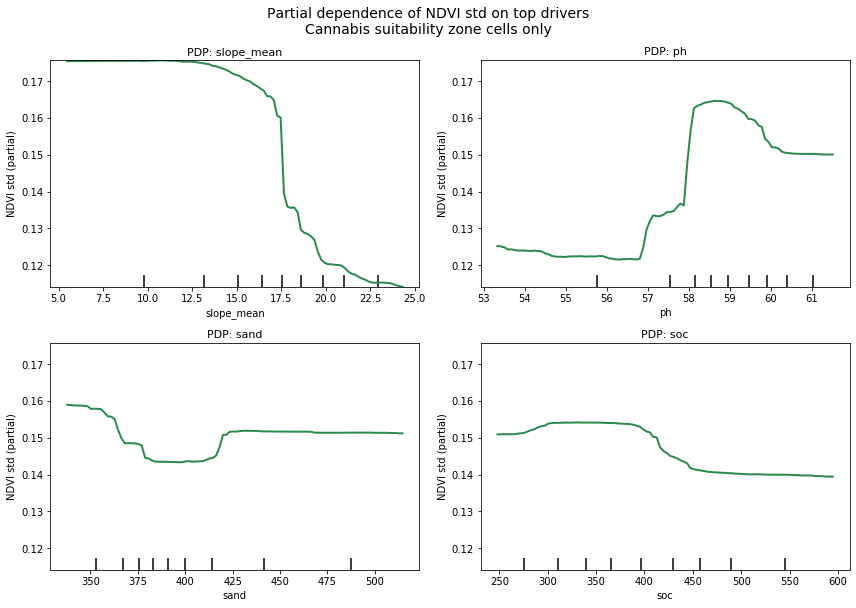

Saved img/ML03_ndvi_pdp.png


In [7]:
top_features = imp.tail(4).index.tolist()[::-1]
top_idx = [feature_cols.index(f) for f in top_features]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    rf, X, top_idx,
    feature_names=feature_cols,
    ax=axes.flat,
    line_kw={'color': '#2d8a4e', 'linewidth': 2},
    pd_line_kw={'color': '#2d8a4e'},
)
for ax, feat in zip(axes.flat, top_features):
    ax.set_title(f'PDP: {feat}', fontsize=11)
    ax.set_xlabel(feat)
    ax.set_ylabel('NDVI std (partial)')

plt.suptitle(
    'Partial dependence of NDVI std on top drivers\n'
    'Cannabis suitability zone cells only',
    fontsize=14, y = 1.05
)
plt.tight_layout()
plt.savefig('../img/ML03_ndvi_pdp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved img/ML03_ndvi_pdp.png')

## 5. Compare: suitability zone vs. full landscape

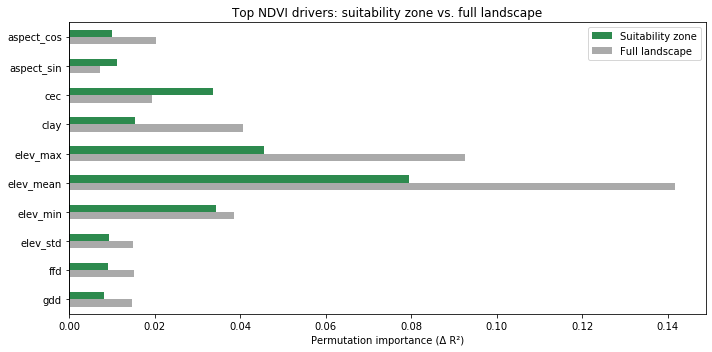

Rank shift — suitability zone vs full landscape:
  slope_mean           zone rank 1  |  full rank 3
  ph                   zone rank 2  |  full rank 1
  sand                 zone rank 3  |  full rank 11
  soc                  zone rank 4  |  full rank 2
  elev_mean            zone rank 5  |  full rank 4
  elev_max             zone rank 6  |  full rank 5
  elev_min             zone rank 7  |  full rank 8
  cec                  zone rank 8  |  full rank 13


In [8]:
# Fit same model on all cells, compare importance rankings
all_cells = df[df['ndvi_std'].notna()].copy()
X_all = all_cells[feature_cols].values
y_all = all_cells['ndvi_std'].values

rf_all = RandomForestRegressor(
    n_estimators=300, max_depth=10,
    min_samples_leaf=5, random_state=746837645, n_jobs=-1
)
rf_all.fit(X_all, y_all)
perm_all = permutation_importance(rf_all, X_all, y_all, n_repeats=10, random_state=42, n_jobs=-1)
imp_all = pd.Series(perm_all.importances_mean, index=feature_cols).sort_values(ascending=False)

# Side-by-side comparison
compare = pd.DataFrame({
    'Suitability zone': imp.sort_values(ascending=False),
    'Full landscape':   imp_all,
}).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
compare.plot(kind='barh', ax=ax, color=['#2d8a4e', '#aaaaaa'])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Permutation importance (Δ R²)')
ax.set_title('Top NDVI drivers: suitability zone vs. full landscape', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../img/ML03_ndvi_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Rank shift — suitability zone vs full landscape:')
for feat in imp.tail(8).index[::-1]:
    rank_sz  = list(imp.sort_values(ascending=False).index).index(feat) + 1
    rank_all = list(imp_all.index).index(feat) + 1 if feat in imp_all.index else '—'
    print(f'  {feat:<20} zone rank {rank_sz}  |  full rank {rank_all}')

## 6. Save

In [9]:
with open(PROC / 'ndvi_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

print('Saved data/processed/ndvi_model.pkl')
print()
print(f'CV R²: {cv_r2.mean():.3f}')
print(f'Top NDVI drivers within suitability zone:')
print(imp.tail(5).iloc[::-1].round(4).to_string())
print()
print('Next: ML/04_similarity_search.ipynb — analog finder + suitability map')

Saved data/processed/ndvi_model.pkl

CV R²: 0.650
Top NDVI drivers within suitability zone:
slope_mean    0.5862
ph            0.3901
sand          0.1301
soc           0.1075
elev_mean     0.0794

Next: ML/04_similarity_search.ipynb — analog finder + suitability map
